## Przygotowanie do grupowania

Wczytujemy dane hoteli i przygotowujemy zestaw cech opisujących m.in. oceny, popularność, ranking oraz poziom cen.

In [1]:
import numpy as np
import pandas as pd

In [2]:
hotels = pd.read_csv('data/full/hotels.csv')
hotels.head(2)

,location_id,address_obj.state,name_details,latitude,longitude,rating,num_reviews,photo_count,price_level,amenities,...,subratings.1.localized_name,subratings.1.value,subratings.2.localized_name,subratings.2.value,subratings.3.localized_name,subratings.3.value,subratings.4.localized_name,subratings.4.value,subratings.5.localized_name,subratings.5.value
0,278399,Podlaskie Province,Hotel Cristal Bialystok,53.132675,23.155990,4.5,390,221,$,"['Internet', 'Suites', 'Room service', 'Free I...",...,Sleep Quality,4.3,Rooms,4.3,Service,4.7,Value,4.3,Cleanliness,4.6
1,10050636,Podlaskie Province,Ibis Styles Bialystok,53.136300,23.162004,4.5,375,302,$,"['Internet', 'Kids Activities', 'Suites', 'Roo...",...,Sleep Quality,4.7,Rooms,4.6,Service,4.6,Value,4.5,Cleanliness,4.8


## Feature engineering

Tworzymy cechy do clusteringu na podstawie ocen, rankingu, poziomu ceny oraz ujednoliconych subratings.

In [3]:
hotels_features = hotels.copy()

subrating_map = {
    "Location": "location_rating",
    "Rooms": "rooms_rating",
    "Service": "service_rating",
    "Value": "value_rating",
    "Cleanliness": "cleanliness_rating",
}

for new_col in subrating_map.values():
    hotels_features[new_col] = np.nan

for idx in range(6):
    name_col = f"subratings.{idx}.localized_name"
    value_col = f"subratings.{idx}.value"

    for localized_name, new_col in subrating_map.items():
        mask = hotels_features[name_col].eq(localized_name)
        hotels_features.loc[mask, new_col] = hotels_features.loc[mask, value_col]

rating_count_cols = [
    "review_rating_count.1",
    "review_rating_count.2",
    "review_rating_count.3",
    "review_rating_count.4",
    "review_rating_count.5",
]

# total_rating_count = hotels_features[rating_count_cols].sum(axis=1)

# hotels_features["bad_review_share"] = (
#     hotels_features["review_rating_count.1"] + hotels_features["review_rating_count.2"]
# ) / total_rating_count.replace(0, np.nan)

# hotels_features["excellent_review_share"] = (
#     hotels_features["review_rating_count.5"] / total_rating_count.replace(0, np.nan)
# )

hotels_features["bad_review_share"] = np.nan
hotels_features["excellent_review_share"] = np.nan

has_no_reviews = hotels_features["num_reviews"].eq(0)
has_reviews = hotels_features["num_reviews"].gt(0)

hotels_features.loc[has_no_reviews, "bad_review_share"] = 0
hotels_features.loc[has_no_reviews, "excellent_review_share"] = 0

has_bad_counts = (
    hotels_features["review_rating_count.1"].notna()
    & hotels_features["review_rating_count.2"].notna()
)

has_excellent_counts = hotels_features["review_rating_count.5"].notna()

hotels_features.loc[has_reviews & has_bad_counts, "bad_review_share"] = (
    hotels_features["review_rating_count.1"]
    + hotels_features["review_rating_count.2"]
) / hotels_features["num_reviews"]

hotels_features.loc[has_reviews & has_excellent_counts, "excellent_review_share"] = (
    hotels_features["review_rating_count.5"]
    / hotels_features["num_reviews"]
)


hotels_features["log_num_reviews"] = np.log1p(hotels_features["num_reviews"])
hotels_features["ranking_ratio"] = (
    hotels_features["ranking_data.ranking"] / hotels_features["ranking_data.ranking_out_of"]
)
hotels_features["price_level_num"] = hotels_features["price_level"].map({
    "$": 1,
    "$$": 2,
    "$$$": 3,
    "$$$$": 4,
})

quality_rating_cols = list(subrating_map.values())
hotels_features["n_subratings"] = hotels_features[quality_rating_cols].notna().sum(axis=1)

ALPHA = 5
hotels_features["subratings_confidence"] = (
    hotels_features["n_subratings"] / (hotels_features["n_subratings"] + ALPHA)
)

features_final = [
    "rating",
    "log_num_reviews",
    "ranking_ratio",
    "price_level_num",
    "bad_review_share",
    "excellent_review_share",
    "location_rating",
    "rooms_rating",
    "service_rating",
    "value_rating",
    "cleanliness_rating",
    "subratings_confidence",
]

df_model_raw = hotels_features[features_final]
df = df_model_raw.fillna(df_model_raw.median(numeric_only=True))

df.head()

,rating,log_num_reviews,ranking_ratio,price_level_num,bad_review_share,excellent_review_share,location_rating,rooms_rating,service_rating,value_rating,cleanliness_rating,subratings_confidence
0,4.5,5.968708,0.062500,1.0,0.015385,0.587179,4.8,4.3,4.7,4.3,4.6,0.5
1,4.5,5.929589,0.031250,1.0,0.040000,0.642667,4.8,4.6,4.6,4.5,4.8,0.5
2,4.4,3.091042,0.375000,2.0,0.047619,0.619048,4.7,4.2,4.4,4.6,4.6,0.5
3,3.5,1.945910,0.687500,2.0,0.333333,0.500000,1.0,3.0,3.3,3.0,1.0,0.5
4,4.3,1.386294,0.061856,1.0,0.000000,0.333333,5.0,4.0,4.5,4.0,4.0,0.5


In [4]:
print(df.isna().sum())

df.describe().T.round(3)

rating                    0
log_num_reviews           0
ranking_ratio             0
price_level_num           0
bad_review_share          0
excellent_review_share    0
location_rating           0
rooms_rating              0
service_rating            0
value_rating              0
cleanliness_rating        0
subratings_confidence     0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
rating,135.0,4.264,0.462,2.300,4.100,4.400,4.500,5.000
log_num_reviews,135.0,4.889,2.044,0.000,3.418,5.159,6.512,8.299
ranking_ratio,135.0,0.207,0.196,0.002,0.065,0.141,0.283,1.000
price_level_num,135.0,1.859,0.682,1.000,1.000,2.000,2.000,4.000
bad_review_share,135.0,0.076,0.094,0.000,0.022,0.050,0.092,0.667
excellent_review_share,135.0,0.537,0.235,0.000,0.369,0.560,0.677,1.000
location_rating,135.0,4.524,0.542,1.000,4.400,4.700,4.800,5.000
rooms_rating,135.0,4.290,0.495,2.400,4.100,4.400,4.600,5.000
service_rating,135.0,4.347,0.472,1.000,4.200,4.400,4.600,5.000
value_rating,135.0,4.249,0.473,2.000,4.100,4.300,4.500,5.000


In [5]:
subratings_check_cols = ["name_details"]
for idx in range(6):
    subratings_check_cols.extend([
        f"subratings.{idx}.localized_name",
        f"subratings.{idx}.value",
    ])

hotels_features[
    subratings_check_cols + [
        "location_rating",
        "rooms_rating",
        "service_rating",
        "value_rating",
        "cleanliness_rating",
        "n_subratings",
        "subratings_confidence",
    ]
].head(8)

,name_details,subratings.0.localized_name,subratings.0.value,subratings.1.localized_name,subratings.1.value,subratings.2.localized_name,subratings.2.value,subratings.3.localized_name,subratings.3.value,subratings.4.localized_name,subratings.4.value,subratings.5.localized_name,subratings.5.value,location_rating,rooms_rating,service_rating,value_rating,cleanliness_rating,n_subratings,subratings_confidence
0,Hotel Cristal Bialystok,Location,4.8,Sleep Quality,4.3,Rooms,4.3,Service,4.7,Value,4.3,Cleanliness,4.6,4.8,4.3,4.7,4.3,4.6,5,0.500000
1,Ibis Styles Bialystok,Location,4.8,Sleep Quality,4.7,Rooms,4.6,Service,4.6,Value,4.5,Cleanliness,4.8,4.8,4.6,4.6,4.5,4.8,5,0.500000
2,Hampton by Hilton Bialystok,Location,4.7,Sleep Quality,3.0,Rooms,4.2,Service,4.4,Value,4.6,Cleanliness,4.6,4.7,4.2,4.4,4.6,4.6,5,0.500000
3,Mercure Bialystok,Sleep Quality,3.7,Rooms,3.0,Location,1.0,Service,3.3,Value,3.0,Cleanliness,1.0,1.0,3.0,3.3,3.0,1.0,5,0.500000
4,Hostel Bialystok Centrum,Location,5.0,Sleep Quality,4.0,Rooms,4.0,Service,4.5,Value,4.0,Cleanliness,4.0,5.0,4.0,4.5,4.0,4.0,5,0.500000
5,Apartamenty Bialystok - Lipowa 12,Sleep Quality,5.0,Service,4.0,Cleanliness,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,5.0,2,0.285714
6,Hotel Branicki,Location,4.7,Sleep Quality,4.5,Rooms,4.5,Service,4.6,Value,4.4,Cleanliness,4.6,4.7,4.5,4.6,4.4,4.6,5,0.500000
7,Royal Hotel & Spa,Location,4.6,Sleep Quality,4.2,Rooms,4.3,Service,4.2,Value,4.0,Cleanliness,4.7,4.6,4.3,4.2,4.0,4.7,5,0.500000


## Macierz Korelacji:

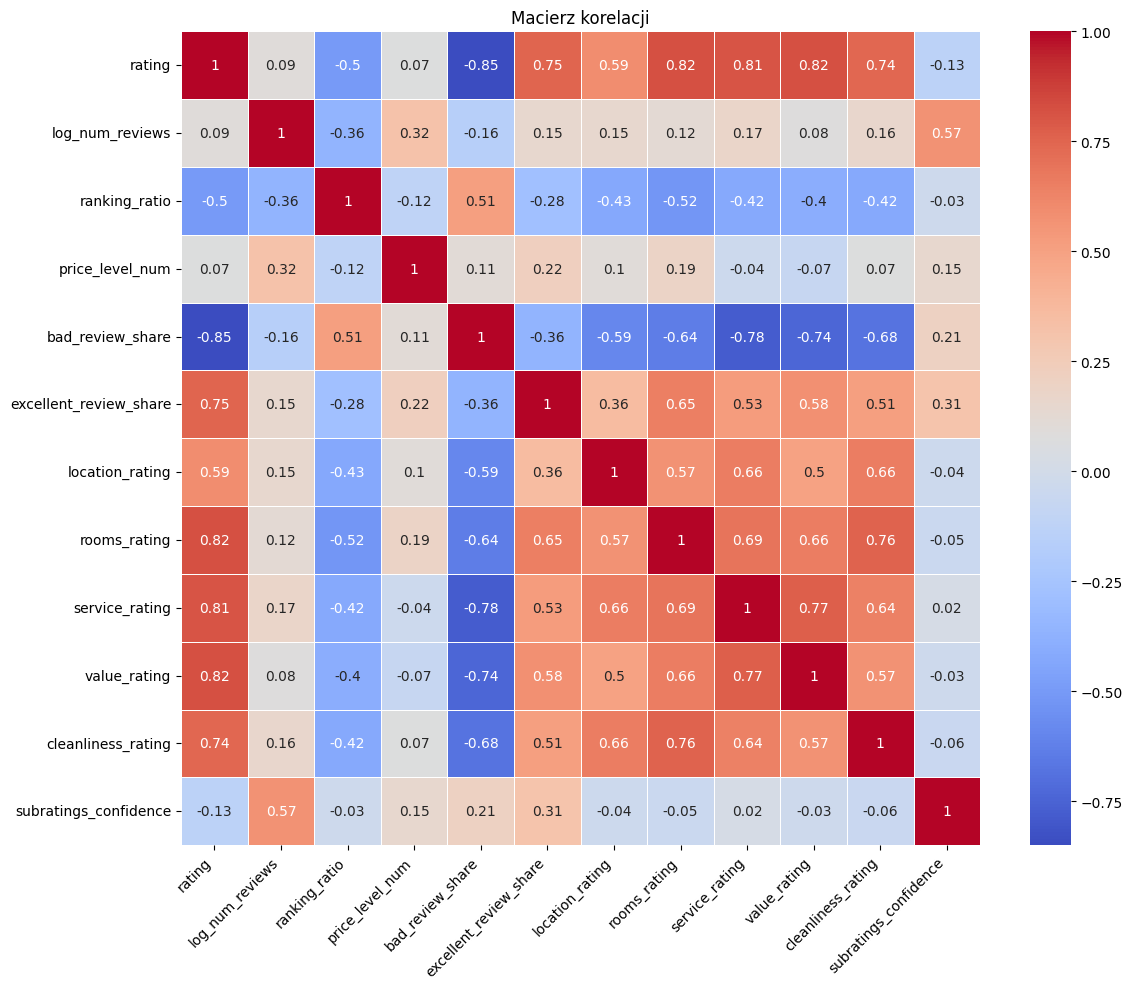

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True).round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.xticks(rotation=45, ha="right")
plt.title("Macierz korelacji")
plt.tight_layout()
plt.show()


In [7]:
corr = df.corr(numeric_only=True)

high_corr = []

for col1 in corr.columns:
    for col2 in corr.columns:

        if col1 != col2:

            value = corr.loc[col1, col2]

            if abs(value) > 0.8:

                pair = tuple(sorted([col1, col2]))

                if pair not in high_corr:
                    high_corr.append(pair)

for col1, col2 in high_corr:

    value = corr.loc[col1, col2]

    print(f"{col1} <-> {col2} = {value:.2f}")

bad_review_share <-> rating = -0.85
rating <-> rooms_rating = 0.82
rating <-> service_rating = 0.81
rating <-> value_rating = 0.82


## Skalowanie cech

Przed uruchomieniem KMeans standaryzujemy wartości, aby cechy zapisane w różnych skalach miały porównywalny wpływ na grupowanie.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df)

## Dobór k w KMeans

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

import matplotlib.pyplot as plt
import pandas as pd

results = []

K_RANGE = range(2, 11)

for k in K_RANGE:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    inertia = model.inertia_

    silhouette = silhouette_score(X, labels)

    calinski = calinski_harabasz_score(X, labels)

    davies = davies_bouldin_score(X, labels)

    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })

    # print(f"\nK = {k}")
    # print(f"Inertia: {inertia:.2f}")
    # print(f"Silhouette Score: {silhouette:.4f}")
    # print(f"Calinski-Harabasz: {calinski:.2f}")
    # print(f"Davies-Bouldin: {davies:.4f}")

results_df = pd.DataFrame(results)

### Summary:

In [10]:
print("\nBest Silhouette:")
print(results_df.loc[
    results_df["silhouette"].idxmax()
])

print("\nBest Calinski-Harabasz:")
print(results_df.loc[
    results_df["calinski_harabasz"].idxmax()
])

print("\nBest Davies-Bouldin:")
print(results_df.loc[
    results_df["davies_bouldin"].idxmin()
])

print("\nLowest Inertia:")
print(results_df.loc[
    results_df["inertia"].idxmin()
])


Best Silhouette:
k                       2.000000
inertia              1123.726902
silhouette              0.379293
calinski_harabasz      58.736978
davies_bouldin          1.227488
Name: 0, dtype: float64

Best Calinski-Harabasz:
k                       2.000000
inertia              1123.726902
silhouette              0.379293
calinski_harabasz      58.736978
davies_bouldin          1.227488
Name: 0, dtype: float64

Best Davies-Bouldin:
k                      4.000000
inertia              744.287896
silhouette             0.326037
calinski_harabasz     51.377201
davies_bouldin         1.034877
Name: 2, dtype: float64

Lowest Inertia:
k                     10.000000
inertia              445.797307
silhouette             0.208086
calinski_harabasz     36.582479
davies_bouldin         1.137779
Name: 8, dtype: float64


### Wykresy:

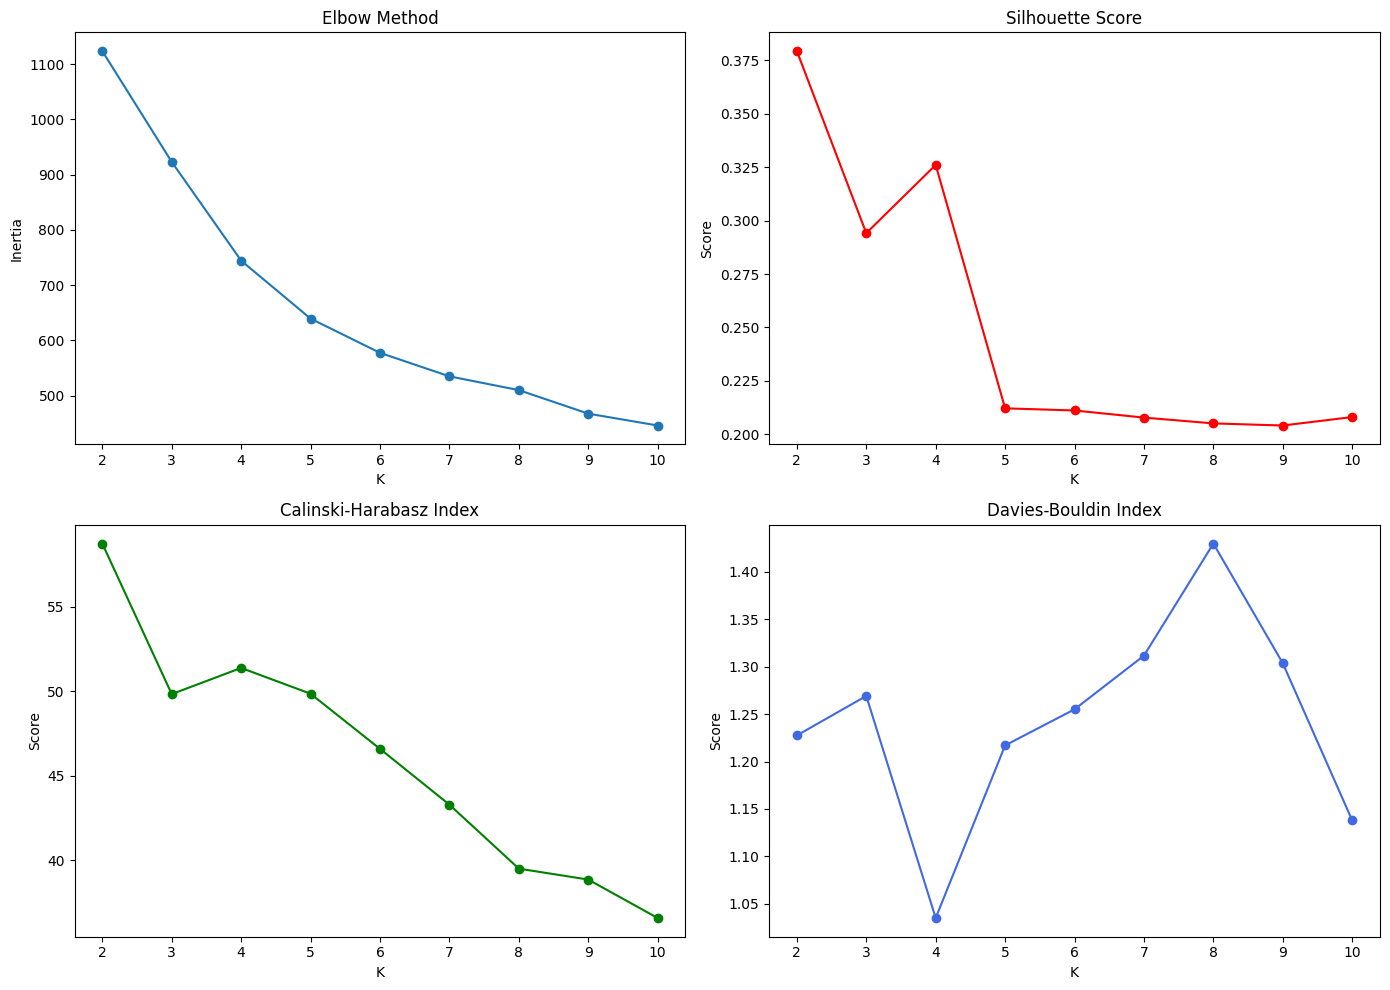

In [11]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

x_ticks = results_df["k"]

# Inertia / Elbow
axes[0, 0].plot(results_df["k"], results_df["inertia"], marker="o")
axes[0, 0].set_title("Elbow Method")
axes[0, 0].set_xlabel("K")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].set_xticks(x_ticks)

# Silhouette
axes[0, 1].plot(results_df["k"], results_df["silhouette"], marker="o", color="red")
axes[0, 1].set_title("Silhouette Score")
axes[0, 1].set_xlabel("K")
axes[0, 1].set_ylabel("Score")
axes[0, 1].set_xticks(x_ticks)

# Calinski-Harabasz
axes[1, 0].plot(results_df["k"], results_df["calinski_harabasz"], marker="o", color="green")
axes[1, 0].set_title("Calinski-Harabasz Index")
axes[1, 0].set_xlabel("K")
axes[1, 0].set_ylabel("Score")
axes[1, 0].set_xticks(x_ticks)

# Davies-Bouldin
axes[1, 1].plot(results_df["k"], results_df["davies_bouldin"], marker="o", color="royalblue")
axes[1, 1].set_title("Davies-Bouldin Index")
axes[1, 1].set_xlabel("K")
axes[1, 1].set_ylabel("Score")
axes[1, 1].set_xticks(x_ticks)

plt.tight_layout()
plt.show()

## Ostateczny model

Na podstawie porównanych metryk wybieramy liczbę klastrów, przypisujemy każdy hotel do grupy i sprawdzamy charakterystykę otrzymanych klastrów.

In [12]:
FINAL_K = 4


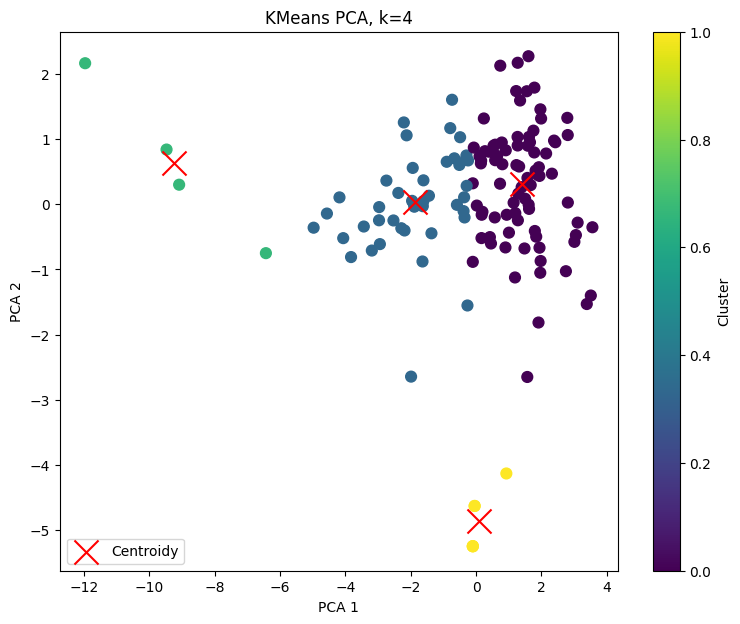

~0.65


In [13]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=60
)
centroids_pca = pca.transform(
    kmeans.cluster_centers_
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="red",
    s=300,
    marker="x",
    label="Centroidy"
)

plt.legend()
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"KMeans PCA, k={FINAL_K}")

plt.colorbar(label="Cluster")
plt.show()


print(f"~{pca.explained_variance_ratio_.sum():.2f}")

In [14]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

clusters = model.fit_predict(X)

df["cluster"] = clusters

In [15]:
print(df["cluster"].value_counts())
df.drop(columns="cluster") \
  .groupby(df["cluster"]) \
  .mean()

cluster
0    82
1    43
3     6
2     4
Name: count, dtype: int64


,rating,log_num_reviews,ranking_ratio,price_level_num,bad_review_share,excellent_review_share,location_rating,rooms_rating,service_rating,value_rating,cleanliness_rating,subratings_confidence
cluster,,,,,,,,,,,,
0,4.523171,5.367845,0.134018,1.975610,0.039435,0.674262,4.702439,4.556098,4.568293,4.471951,4.743902,0.495185
1,3.867442,4.865532,0.306273,1.674419,0.123317,0.351210,4.353488,3.909302,4.067442,3.946512,4.193023,0.493725
2,2.850000,2.479422,0.588441,2.000000,0.445187,0.286542,2.425000,2.775000,2.750000,2.850000,2.350000,0.500000
3,4.500000,0.115525,0.242801,1.500000,0.000000,0.166667,4.700000,4.400000,4.400000,4.300000,4.600000,0.000000


 - Cluster 0 - Najlepsze i najpopularniejsze hotele  
   
    *Wysoko oceniane i bardzo dobrze zweryfikowane hotele. Duża liczba opinii, wysoka jakość usług oraz bardzo dobre oceny użytkowników. Reprezentują najbardziej prestiżową grupę obiektów w zbiorze.*  
      
 - Cluster 1 - Hotele przeciętne / ekonomiczne  
   
    *Hotele o przeciętnej jakości. Posiadają dużą liczbę opinii, jednak oceny użytkowników są wyraźnie niższe niż w najlepszej grupie. Mogą odpowiadać segmentowi ekonomicznemu lub obiektom wymagającym poprawy jakości usług.*  
      
 - Cluster 2 - Problematyczne hotele  

   *Najsłabiej oceniane obiekty w zbiorze. Charakteryzują się dużym udziałem negatywnych opinii, niskimi ocenami użytkowników oraz słabymi wynikami w rankingach. Stanowią grupę hoteli problematycznych.*  


 - Cluster 3 - Hotele bez wystarczającej liczby opinii  
   
   *Hotele, które nie posiadają żadnych opinii.*  
     



## Zapis:

In [16]:
clustered_hotels = hotels.copy()

clustered_hotels["cluster"] = clusters

# clustered_hotels[[
#     "location_id",
#     "address_obj.city_details",
#     "name_details",
#     "rating",
#     "num_reviews",
#     "price_level",
#     "cluster"
# ]].head()
for col in features_final:
    clustered_hotels[col] = df[col]

clustered_hotels.head()  


,location_id,address_obj.state,name_details,latitude,longitude,rating,num_reviews,photo_count,price_level,amenities,...,ranking_ratio,price_level_num,bad_review_share,excellent_review_share,location_rating,rooms_rating,service_rating,value_rating,cleanliness_rating,subratings_confidence
0,278399,Podlaskie Province,Hotel Cristal Bialystok,53.132675,23.155990,4.5,390,221,$,"['Internet', 'Suites', 'Room service', 'Free I...",...,0.062500,1.0,0.015385,0.587179,4.8,4.3,4.7,4.3,4.6,0.5
1,10050636,Podlaskie Province,Ibis Styles Bialystok,53.136300,23.162004,4.5,375,302,$,"['Internet', 'Kids Activities', 'Suites', 'Roo...",...,0.031250,1.0,0.040000,0.642667,4.8,4.6,4.6,4.5,4.8,0.5
2,23643711,Podlaskie Province,Hampton by Hilton Bialystok,53.133140,23.149403,4.4,21,125,$$,['Free Wifi'],...,0.375000,2.0,0.047619,0.619048,4.7,4.2,4.4,4.6,4.6,0.5
3,21356073,Podlaskie Province,Mercure Bialystok,53.129864,23.117730,3.5,6,103,$$,"['Shuttle Bus Service', 'Suites', 'Room servic...",...,0.687500,2.0,0.333333,0.500000,1.0,3.0,3.3,3.0,1.0,0.5
4,23247934,Podlaskie Province,Hostel Bialystok Centrum,53.135296,23.145533,4.3,3,1,$,[],...,0.061856,1.0,0.000000,0.333333,5.0,4.0,4.5,4.0,4.0,0.5


In [17]:
clustered_hotels.to_csv(
    "data/full/hotels_with_clusters.csv",
    index=False,
    encoding="utf-8-sig"
)
clustered_hotels.head(2)

,location_id,address_obj.state,name_details,latitude,longitude,rating,num_reviews,photo_count,price_level,amenities,...,ranking_ratio,price_level_num,bad_review_share,excellent_review_share,location_rating,rooms_rating,service_rating,value_rating,cleanliness_rating,subratings_confidence
0,278399,Podlaskie Province,Hotel Cristal Bialystok,53.132675,23.155990,4.5,390,221,$,"['Internet', 'Suites', 'Room service', 'Free I...",...,0.06250,1.0,0.015385,0.587179,4.8,4.3,4.7,4.3,4.6,0.5
1,10050636,Podlaskie Province,Ibis Styles Bialystok,53.136300,23.162004,4.5,375,302,$,"['Internet', 'Kids Activities', 'Suites', 'Roo...",...,0.03125,1.0,0.040000,0.642667,4.8,4.6,4.6,4.5,4.8,0.5


In [18]:
import joblib
import json
from pathlib import Path

MODEL_DIR = Path("models/clustering")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model, MODEL_DIR / "kmeans_model.joblib")
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
joblib.dump(df_model_raw.median(numeric_only=True), MODEL_DIR / "feature_medians.joblib")

with open(MODEL_DIR / "features_final.json", "w", encoding="utf-8") as f:
    json.dump(features_final, f, ensure_ascii=False, indent=2)
